In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
import itertools

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy
from collections import defaultdict
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import euclidean
import matplotlib.lines as mlines

sc.settings.verbosity = 1

# Load in processed data

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.38 GB, difference +2.38 GB
CPU times: user 537 ms, sys: 1.94 s, total: 2.48 s
Wall time: 3.94 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

In [3]:
adata.var.head()

,gene_id,gene_type,Chromosome,Start,End,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,...,total_counts,log1p_total_counts,n_counts,filter_pass,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches
gene_name,,,,,,,,,,,,,,,,,,,,,
A1BG,ENSG00000121410,protein_coding,chr19,58345177,58353492,False,False,8565,0.743217,0.555732,...,14353.0,9.571784,13983.0,True,False,NaN,0.395181,0.190637,1.027514,0
A1BG-AS1,ENSG00000268895,lncRNA,chr19,58347717,58355455,False,False,1339,0.074461,0.071820,...,1438.0,7.271704,1379.0,False,False,NaN,0.047152,0.028002,0.964666,0
A1CF,ENSG00000148584,protein_coding,chr10,50799408,50885675,False,False,74,0.004091,0.004082,...,79.0,4.382027,77.0,True,False,NaN,0.002697,0.001801,0.962377,0
A2M,ENSG00000175899,protein_coding,chr12,9067663,9116229,False,False,1100,0.082850,0.079596,...,1600.0,7.378384,1568.0,True,True,365.0,0.046370,0.035322,1.174857,1
A2M-AS1,ENSG00000245105,lncRNA,chr12,9065162,9068689,False,False,64,0.003314,0.003309,...,64.0,4.174387,64.0,False,False,NaN,0.002294,0.001406,0.955376,0


In [3]:
adata.var['gene_name'] = adata.var_names

adata.var.head()

,gene_id,gene_type,Chromosome,Start,End,mt,ribo,n_cells_by_counts,mean_counts,log1p_mean_counts,...,log1p_total_counts,n_counts,filter_pass,highly_variable,highly_variable_rank,means,variances,variances_norm,highly_variable_nbatches,gene_name
gene_name,,,,,,,,,,,,,,,,,,,,,
A1BG,ENSG00000121410,protein_coding,chr19,58345177,58353492,False,False,8565,0.743217,0.555732,...,9.571784,13983.0,True,False,NaN,0.395181,0.190637,1.027514,0,A1BG
A1BG-AS1,ENSG00000268895,lncRNA,chr19,58347717,58355455,False,False,1339,0.074461,0.071820,...,7.271704,1379.0,False,False,NaN,0.047152,0.028002,0.964666,0,A1BG-AS1
A1CF,ENSG00000148584,protein_coding,chr10,50799408,50885675,False,False,74,0.004091,0.004082,...,4.382027,77.0,True,False,NaN,0.002697,0.001801,0.962377,0,A1CF
A2M,ENSG00000175899,protein_coding,chr12,9067663,9116229,False,False,1100,0.082850,0.079596,...,7.378384,1568.0,True,True,365.0,0.046370,0.035322,1.174857,1,A2M
A2M-AS1,ENSG00000245105,lncRNA,chr12,9065162,9068689,False,False,64,0.003314,0.003309,...,4.174387,64.0,False,False,NaN,0.002294,0.001406,0.955376,0,A2M-AS1


In [9]:
hvg = adata.var[adata.var['highly_variable']]

hvg = hvg[['gene_name', 'gene_type', 'highly_variable_rank', 'filter_pass']]

hvg = hvg[~hvg['gene_name'].str.startswith('ENSG')]

hvg = hvg.sort_values(by='highly_variable_rank', ascending=True)

print(hvg.shape)
hvg.head(10)

(1524, 4)


,gene_name,gene_type,highly_variable_rank,filter_pass
gene_name,,,,
IFNL1,IFNL1,protein_coding,2.0,True
CCL2,CCL2,protein_coding,3.5,True
IGFBP5,IGFBP5,protein_coding,8.5,True
IFIT2,IFIT2,protein_coding,9.5,True
CCL4L2,CCL4L2,protein_coding,10.0,True
LINC01721,LINC01721,lncRNA,11.0,False
CXCL8,CXCL8,protein_coding,11.0,True
CCL5,CCL5,protein_coding,12.5,True
IFNL3,IFNL3,protein_coding,13.0,True


In [12]:
hvg['gene_name'][:30]

gene_name
IFNL1            IFNL1
CCL2              CCL2
IGFBP5          IGFBP5
IFIT2            IFIT2
CCL4L2          CCL4L2
LINC01721    LINC01721
CXCL8            CXCL8
CCL5              CCL5
IFNL3            IFNL3
IFI27            IFI27
LINC02840    LINC02840
CCL4              CCL4
RHAG              RHAG
MMP1              MMP1
TMEM108        TMEM108
IFNL2            IFNL2
LINC01456    LINC01456
LINC01419    LINC01419
PAK5              PAK5
S100A4          S100A4
CCL3L3          CCL3L3
LINC02607    LINC02607
LINC01682    LINC01682
IFNB1            IFNB1
LINC02319    LINC02319
TOP2A            TOP2A
IFNA10          IFNA10
MGP                MGP
G2E3-AS1      G2E3-AS1
HMGB2            HMGB2
Name: gene_name, dtype: object

In [30]:
def compute_von_neumann_entropy(W):
    """Von Neumann graph entropy of adjacency/similarity matrix W"""
    D = np.diag(W.sum(axis=1))
    L = D - W
    eigvals = np.linalg.eigvalsh(L)
    eigvals = eigvals[eigvals > 1e-12]  # numerical stability
    if eigvals.sum() == 0:
        return np.nan
    eigvals /= eigvals.sum()
    return -np.sum(eigvals * np.log(eigvals))

def compute_node_entropies(W):
    """Node entropies based on normalized edge weights"""
    if W.ndim != 2 or W.shape[0] == 0:
        return np.array([])
    row_sums = W.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid divide-by-zero
    W_norm = W / row_sums
    return entropy(W_norm, axis=1, base=np.e)  # entropy per node

In [ ]:
%%time

results = {}

# Subset to highly variable genes
sdata = adata[:, adata.var['highly_variable']].copy()

# Pick log-normalized data if available
if "log_norm" in sdata.layers:
    X_full = sdata.layers["log_norm"]
else:
    X_full = sdata.X

for cond in sdata.obs['pooled_condition'].unique():
    print(f"Processing condition: {cond}")

    adata_sub = sdata[sdata.obs['pooled_condition'] == cond]
    X = adata_sub.X

    if hasattr(X, "A"):
        X = X.A
    else:
        X = np.array(X)

    print(f"\tShape before correlation: {X.shape}")

    if X.shape[0] < 2 or X.shape[1] < 2:
        print(f"\tSkipping {cond}: too few cells or genes ({X.shape})")
        continue

    print("\tComputing gene-gene correlation distances...")
    try:
        dist_vector = pdist(X.T, metric="correlation")  # genes × genes
    except Exception as e:
        print(f"\tSkipping {cond} due to pdist error: {e}")
        continue

    if dist_vector.size == 0:
        print(f"\tSkipping {cond}: empty distance matrix")
        continue

    corr = 1 - squareform(dist_vector)
    dist = 1 - np.abs(corr)

    sigma = np.median(dist)
    if sigma == 0:
        print(f"\tSkipping {cond}: sigma=0")
        continue

    W = np.exp(-dist**2 / (2 * sigma**2))
    np.fill_diagonal(W, 0)

    vn_entropy = compute_von_neumann_entropy(W)
    node_ent = compute_node_entropies(W)

    genes = sdata.var_names  # correct gene names for subset

    results[cond] = {
        "vn_entropy": vn_entropy,
        "node_entropy": pd.Series(node_ent, index=genes)
    }

    print(f"\tVN entropy = {vn_entropy:.3f}")

    break

# Load in genesets

In [4]:
path1 = "../../resources/HWG/MYOD Influencers.csv"
path2 = "../../resources/HWG/MYOD Target.csv"
path3 = "../../resources/HWG/PRRX1 Influencers.csv"
path4 = "../../resources/HWG/PRRX1 Target.csv"

def load_and_rename(path, gene, role):
    df = pd.read_csv(path)
    df = df.rename(columns={
        f"{gene} {role}": "gene",
        f"{gene} {role} ID": "gene_id",
        f"{gene} {role} degree centrality": "degree_centrality",
        f"{gene} {role} Eigenvector centrality": "eigenvector_centrality"
    })
    return df

myod_inf = load_and_rename(path1, "MYOD", "Influencer")
myod_tar = load_and_rename(path2, "MYOD", "Target")
prrx_inf = load_and_rename(path3, "PRRX1", "Influencer")
prrx_tar = load_and_rename(path4, "PRRX1", "Target")

for name, df in zip(
    ["MYOD Influencers", "MYOD Targets", "PRRX1 Influencers", "PRRX1 Targets"],
    [myod_inf, myod_tar, prrx_inf, prrx_tar]
):
    print(f"{name}: {df['gene'].nunique()} unique genes ({df.shape[0]} rows)")

MYOD Influencers: 170 unique genes (170 rows)
MYOD Targets: 544 unique genes (544 rows)
PRRX1 Influencers: 78 unique genes (78 rows)
PRRX1 Targets: 195 unique genes (195 rows)


In [5]:
def load_pathway(fpath):
    result = []
    with open(fpath) as f:
        for line in f:
            split_line = [x for x in line.strip().split('\t') if x]  # Remove empty strings directly

            row = {'label': split_line[0]}
            for gene in split_line[1:]:
                row[gene] = 1

            result.append(row)

    df = pd.DataFrame(result)
    df = df.fillna(0.0).set_index('label').astype(bool).T  # Chained operations for clarity

    return df

mpath = "/nfs/turbo/umms-indikar/shared/projects/RECODE/marker_genes/PanglaoDB_Augmented_2021.txt"
pang = load_pathway(mpath)

cell_types = [
    'Fibroblasts',
    'Myocytes',
    'Myoblasts',
    'Myofibroblasts',
    'Pluripotent Stem Cells'
]

subset = pang[cell_types]

print("Marker genes per cell type:")
for ct in cell_types:
    print(f"{ct}: {subset[ct].sum()}")

panglao_markers = subset[subset.any(axis=1)]

print(f"\nTotal unique genes across selected types: {panglao_markers.shape[0]}")
panglao_markers.head()

fib_genes = panglao_markers['Fibroblasts'] == True
fib_genes =  panglao_markers[fib_genes].index
fib_genes = [g for g in fib_genes if g in adata.var_names]
print(len(fib_genes))


myo_genes = panglao_markers['Myocytes'] == True
myo_genes =  panglao_markers[myo_genes].index
myo_genes = [g for g in myo_genes if g in adata.var_names]
print(len(myo_genes))

Marker genes per cell type:
Fibroblasts: 232
Myocytes: 163
Myoblasts: 126
Myofibroblasts: 100
Pluripotent Stem Cells: 112

Total unique genes across selected types: 563
220
123


In [8]:
[col for col in pang if 'hk' in col.lower()]

[]

# Gene-gene A matrices

In [190]:
# Subset for genes of interest
gene_list = fib_genes.copy()
gene_list = [g for g in gene_list if g in adata.var_names]

bdata = adata[:, gene_list].copy()
print(bdata.shape)

bdata.X = bdata.layers['log_norm'].copy()

adjacency_matrices_unsigned = {}
adjacency_matrices_signed = {}

for cond, group in bdata.obs.groupby('pooled_condition', observed=True):
    print(f"Computing A matrix for {cond} ({len(group)} cells)")
    cell_idx = group.index
    
    # compute pearson correlation
    A = bdata[cell_idx, :].to_df().corr()
    np.fill_diagonal(A.values, 0)
    print(A.shape)
    
    # unsigned network (absolute correlation)
    A_unsigned = A.abs().copy()
    
    # signed, rescaled network --- shift correlation from [-1, 1] → [0, 1]
    A_signed = (A + 1) / 2
    np.fill_diagonal(A_signed.values, 0)
    
    adjacency_matrices_unsigned[cond] = A_unsigned
    adjacency_matrices_signed[cond] = A_signed

(15950, 220)
Computing A matrix for Control (6960 cells)
(220, 220)
Computing A matrix for mmMYOD1 (2109 cells)
(220, 220)
Computing A matrix for siPRRX1 (3430 cells)
(220, 220)
Computing A matrix for siPRRX1/mmMYOD1 (3451 cells)
(220, 220)


## Unsigned adjacency matrices

In [191]:
adjacency_matrices = adjacency_matrices_unsigned.copy()

entropies = {}
KL_divergences = {}

top_edges_per_condition = {}
top_genes_per_condition = {}

# entropy
for cond, A in adjacency_matrices.items():
    upper_tri = np.triu_indices_from(A, k=1)
    values = A.values[upper_tri]
    values = values[~np.isnan(values)]
    
    p = values / np.sum(values)
    H = -np.sum(p * np.log2(p + 1e-12))
    entropies[cond] = H
    
entropy_df = pd.DataFrame(list(entropies.items()), columns=['condition', 'entropy'])
entropy_df = entropy_df.sort_values('entropy', ascending=False)

# KL divergence
control_A = adjacency_matrices['Control']
upper_tri = np.triu_indices_from(control_A, k=1)
print(f"Total edges in upper triangle: {len(control_A.values[upper_tri])}")

for condition, A in adjacency_matrices.items():
    mask_cond = ~np.isnan(A.values[upper_tri])
    print(f"{condition}: {mask_cond.sum()} edges")


# Create consistent mask based on edges that exist in *all* conditions
mask_upper = np.ones_like(control_A.values[upper_tri], dtype=bool)
for A in adjacency_matrices.values():
    mask_upper &= ~np.isnan(A.values[upper_tri])  # keep only edges present in all
    
print(f"Edges present in all conditions: {mask_upper.sum()} / {len(mask_upper)}")

control_values = np.abs(control_A.values[upper_tri][mask_upper])
p_control = control_values / np.sum(control_values)

genes = control_A.columns

n_top = 50

for condition, A in adjacency_matrices.items():
    if condition == 'Control':
        KL_divergences[condition] = 0.0
        continue

    values = np.abs(A.values[upper_tri][mask_upper]) # same mask

    if np.sum(values) == 0:
        KL_divergences[condition] = np.nan
        print(f"⚠️ Condition {condition} has zero-sum adjacency values → KL undefined")
        continue

    p_cond = values / np.sum(values)

    # Add small constant to avoid log(0)
    eps = 1e-12
    p_cond += eps
    p_control_adj = p_control + eps

    KL = np.sum(p_cond * np.log2(p_cond / p_control_adj))
    KL_divergences[condition] = KL
    
    # --- TOP EDGES ---
    delta = p_cond * np.log2(p_cond / p_control_adj)
    edges = [(genes[i], genes[j]) for i, j in zip(*upper_tri)]
    edges = np.array(edges)[mask_upper]

    df_edges = pd.DataFrame({
        "gene_i": edges[:, 0],
        "gene_j": edges[:, 1],
        "delta_KL": delta
    }).sort_values(by="delta_KL", ascending=False)

    top_edges_per_condition[condition] = df_edges.head(n_top)   
    
    # --- TOP GENES ---
    gene_importance = pd.concat([
        df_edges.groupby("gene_i")["delta_KL"].sum(),
        df_edges.groupby("gene_j")["delta_KL"].sum()
    ], axis=1).sum(axis=1).sort_values(ascending=False)

    top_genes_per_condition[condition] = gene_importance.head(n_top)
    
      
kl_df = pd.DataFrame(list(KL_divergences.items()), columns=['condition', 'KL_divergence'])
kl_df = kl_df.sort_values('KL_divergence', ascending=False)

display(entropy_df)
display(kl_df)

Total edges in upper triangle: 24090
Control: 23005 edges
mmMYOD1: 23436 edges
siPRRX1: 23871 edges
siPRRX1/mmMYOD1: 24090 edges
Edges present in all conditions: 22578 / 24090


,condition,entropy
2,siPRRX1,13.734990
1,mmMYOD1,13.709156
3,siPRRX1/mmMYOD1,13.675869
0,Control,13.645507


,condition,KL_divergence
3,siPRRX1/mmMYOD1,0.988750
1,mmMYOD1,0.947205
2,siPRRX1,0.714750
0,Control,0.000000


Unsigned adjacency matrix


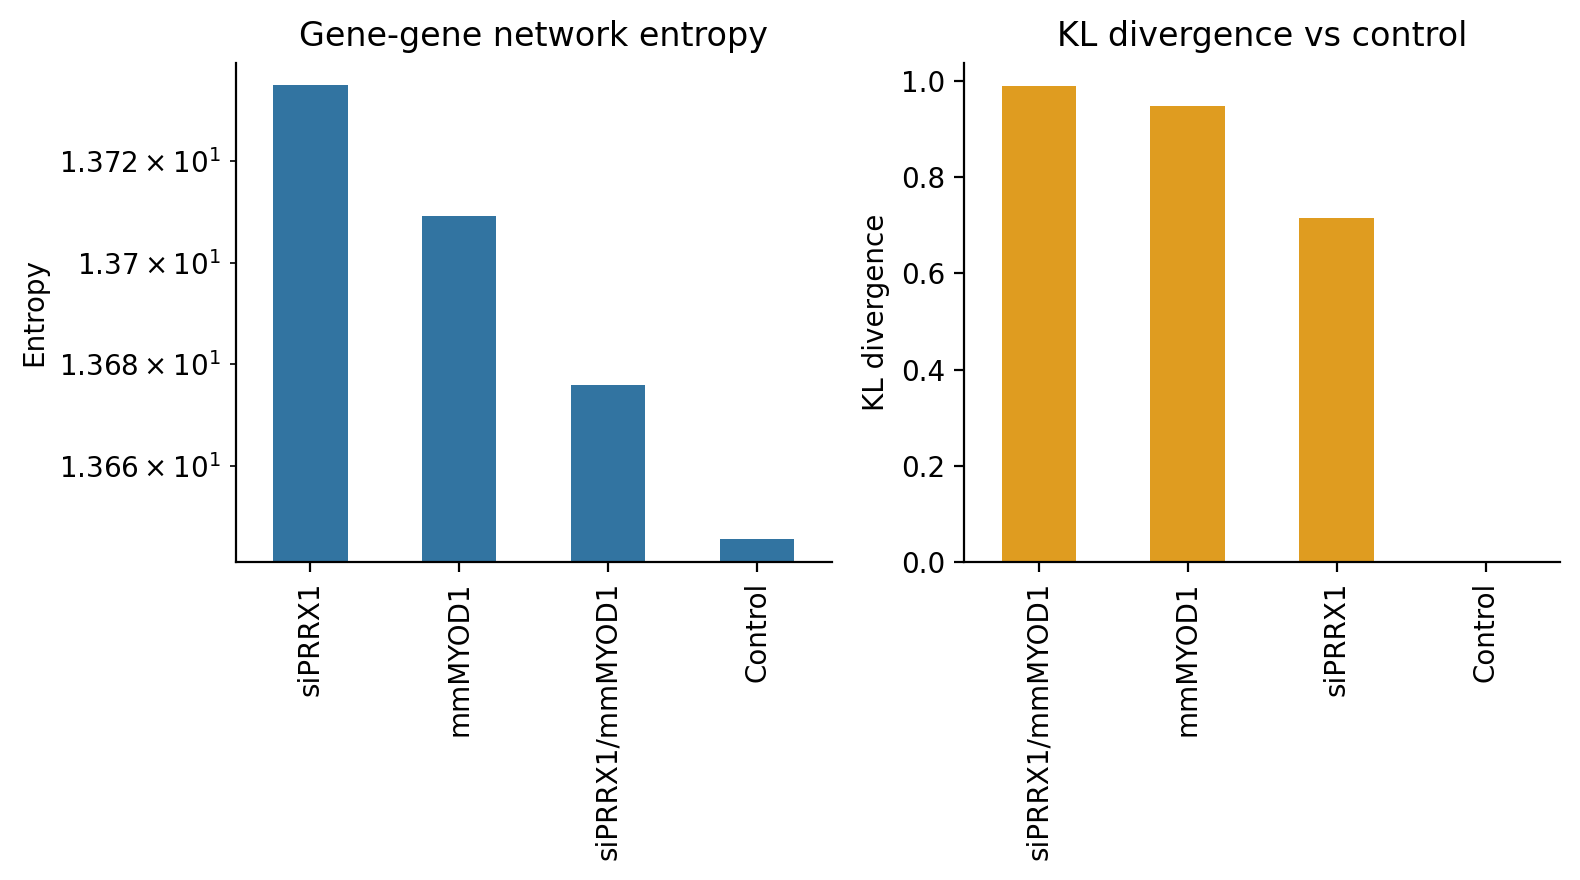

In [192]:
print("Unsigned adjacency matrix")
fig, axes = plt.subplots(1, 2, figsize=(8, 4.5), dpi=200)

sns.barplot(
    data=entropy_df,
    x='condition',
    y='entropy',
    width=0.5,
    ax=axes[0],
)

axes[0].tick_params(axis='x', labelrotation=90)
axes[0].set_xlabel("")
axes[0].set_title("Gene-gene network entropy")
axes[0].set_yscale('log')
axes[0].set_ylabel("Entropy")

sns.barplot(
    data=kl_df,
    x='condition',
    y='KL_divergence',
    width=0.5,
    color='orange',
    ax=axes[1],
)

axes[1].tick_params(axis='x', labelrotation=90)
axes[1].set_xlabel("")
axes[1].set_title("KL divergence vs control")
axes[1].set_ylabel("KL divergence")

sns.despine()
plt.tight_layout()
plt.show()

Shannon entropy (H)
* Measures absolute disorder in the gene-gene network
* Higher H --> more uniform edge distribution --> more "uncertainty" in the network structure
* Lower H --> more concentrated edges --> stronger, more specific co-regulation patterns

KL divergence vs Control
* Measures how different a condition's network is from control (distributions of edge weights)
* Higher KL --> greater change in correlation structure relative to control
* KL = 0 --> networks are identical in terms of edge distribution


In [193]:
top_genes = []

for condition, gene_series in top_genes_per_condition.items():
    df_temp = pd.DataFrame({
        "condition": condition,
        "gene": gene_series.index,
        "KL_sum": gene_series.values # summed KL contribution for a given gene
    })
    top_genes.append(df_temp)

top_genes = pd.concat(top_genes, ignore_index=True)

top_genes.groupby('condition', observed=True).head()

,condition,gene,KL_sum
0,mmMYOD1,RUNX1,0.060048
1,mmMYOD1,MDK,0.042434
2,mmMYOD1,CKAP4,0.039646
3,mmMYOD1,NFKB1,0.039546
4,mmMYOD1,S100A4,0.037524
50,siPRRX1,IGFBP6,0.036059
51,siPRRX1,IGFBP3,0.030519
52,siPRRX1,LAMA4,0.029614
53,siPRRX1,COX7A1,0.028428
54,siPRRX1,LUM,0.024742


In [194]:
top_edges = []

for condition, df_edges in top_edges_per_condition.items():
    df_temp = pd.DataFrame({
        "condition": condition,
        "gene_i": df_edges["gene_i"].values,
        "gene_j": df_edges["gene_j"].values,
        "value": df_edges["delta_KL"].values
    })
    top_edges.append(df_temp)


top_edges = pd.concat(top_edges, ignore_index=True)

top_edges.groupby('condition', observed=True).head()

,condition,gene_i,gene_j,value
0,mmMYOD1,TAGLN,DKK3,0.002677
1,mmMYOD1,RUNX1,ABI3BP,0.002386
2,mmMYOD1,RUNX1,CKAP4,0.002227
3,mmMYOD1,RUNX1,NFKB1,0.002217
4,mmMYOD1,COL1A2,THY1,0.001970
50,siPRRX1,MYL9,DAB2,0.001753
51,siPRRX1,COL1A2,MYL9,0.001638
52,siPRRX1,LOX,CD248,0.001539
53,siPRRX1,C1S,IGFBP3,0.001537
54,siPRRX1,COL6A2,IGFBP6,0.001501


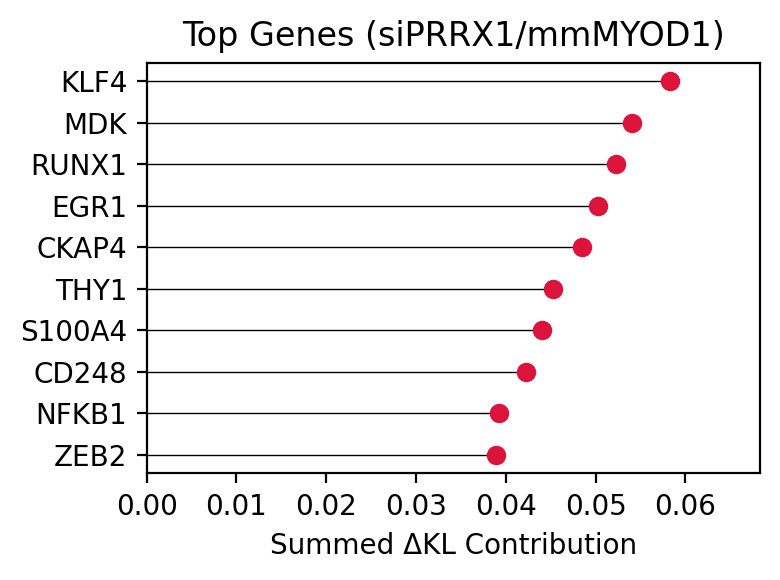

In [195]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 3

cond = 'siPRRX1/mmMYOD1'
genes_plot = top_genes[top_genes["condition"] == cond].sort_values("KL_sum", ascending=False).head(10)
genes_plot = genes_plot[::-1]  # reverse for better visualization (largest on top)

plt.hlines(y=genes_plot["gene"], xmin=0, xmax=genes_plot["KL_sum"], color='k', linewidth=0.5)
plt.plot(genes_plot["KL_sum"], genes_plot["gene"], "o", color="crimson")

plt.gca().margins(x=0)

plt.xlim([0, genes_plot["KL_sum"].max() + 0.01])

plt.xlabel("Summed ΔKL Contribution")
plt.ylabel("")
plt.title(f"Top Genes ({cond})")

# sns.despine()
plt.tight_layout()
plt.show()

30


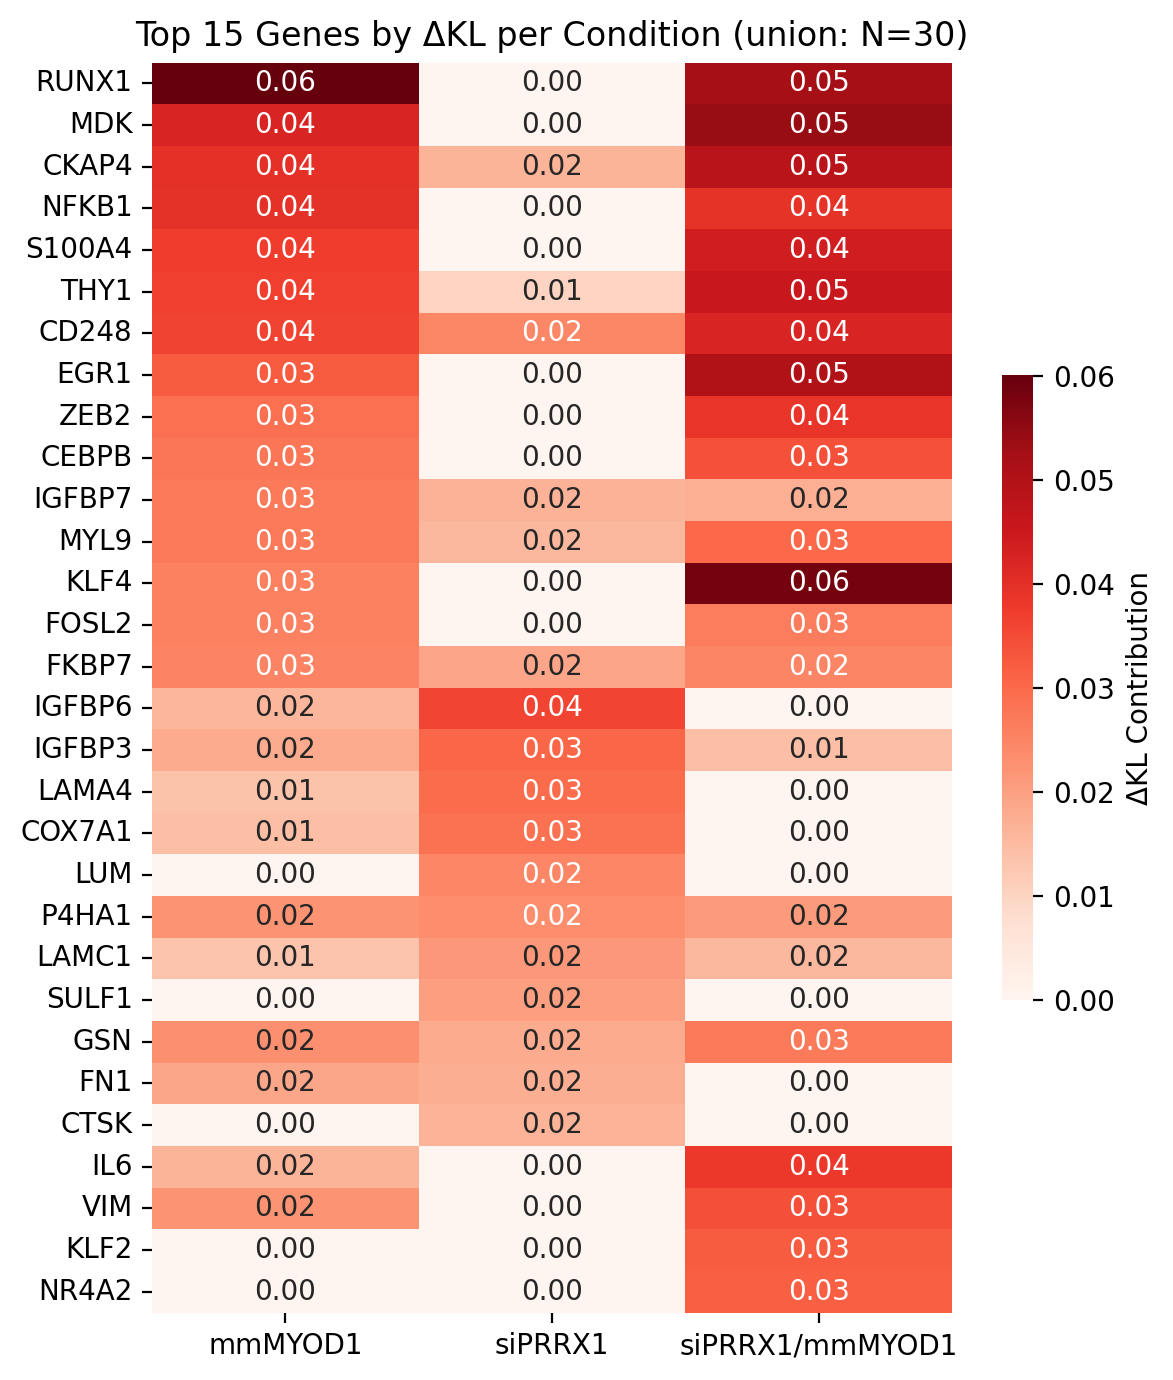

In [173]:
top_n = 15
genes_per_condition = (top_genes.groupby('condition')
                       .apply(lambda df: df.nlargest(top_n, 'KL_sum')['gene'], include_groups=False)
                       .explode()
                       .reset_index(drop=True))

unique_genes = genes_per_condition.unique()
print(len(unique_genes))

heatmap_data = top_genes[top_genes['gene'].isin(unique_genes)].pivot(index="gene", columns="condition", values="KL_sum").fillna(0)
heatmap_data = heatmap_data.reindex(unique_genes)  # Ensures same order as in union list

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 7

sns.heatmap(heatmap_data, cmap="Reds", annot=True, fmt=".2f", cbar_kws={'label': "ΔKL Contribution", "shrink": 0.5})

plt.title(f"Top {top_n} Genes by ΔKL per Condition (union: N={len(unique_genes)})")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Networks

In [66]:
def plot_network(A, title="", top_n_genes=None, top_genes=None, top_edges=None, 
                 edge_threshold=0.5, min_edge_width=0.5, max_edge_width=5):
    """
    Plot a network from adjacency matrix A with thresholding and edge width scaling.
    Centrality is computed on the full graph; thresholding is applied for plotting only.
    
    Params:
        A: pd.DataFrame adjacency matrix (unsigned)
        title: str, title of plot
        top_n_genes: int, number of top genes by centrality to highlight
        top_genes: list of genes to highlight
        top_edges: pd.DataFrame with columns ['gene_i','gene_j','value'] to highlight edges
        edge_threshold: float, min correlation to draw edge
        min_edge_width: float, smallest edge width
        max_edge_width: float, largest edge width
    """
    # Step 1 — full graph for centrality
    G_full = nx.from_pandas_adjacency(A.abs())
    
    # Step 2 — compute eigenvector centrality on full graph
    centrality = nx.eigenvector_centrality_numpy(G_full)

    # Step 3 — create plot graph with threshold applied
    G = nx.Graph()
    genes = A.columns
    for i, gene_i in enumerate(genes):
        for j, gene_j in enumerate(genes):
            if i >= j:
                continue
            weight = A.iloc[i, j]
            if weight >= edge_threshold:
                G.add_edge(gene_i, gene_j, weight=weight)

    if len(G) == 0:
        print(f"No edges above threshold {edge_threshold} for {title}")
        return

    # Step 4 — scale node sizes by centrality
    cent_vals = np.array(list(centrality.values()))
    min_size = 50
    max_size = 500
    node_sizes = min_size + (cent_vals - cent_vals.min()) / (cent_vals.max() - cent_vals.min()) * (max_size - min_size)

    # Step 5 — scale edge widths by correlation strength
    weights = np.array([d["weight"] for u, v, d in G.edges(data=True)])
    if len(weights) == 0:
        edge_widths = []
    else:
        min_w = weights.min()
        max_w = weights.max()
        if max_w == min_w:
            edge_widths = [min_edge_width] * len(weights)
        else:
            edge_widths = min_edge_width + (weights - min_w) / (max_w - min_w) * (max_edge_width - min_edge_width)

    # Step 6 — layout
    pos = nx.spring_layout(G, seed=42, k=1.5)

    plt.figure(figsize=(10, 10))
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5, edge_color="grey")

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_size=[node_sizes[list(G.nodes()).index(n)] for n in G.nodes()], node_color="lightblue")

    # Highlight top genes
    if top_genes is None and top_n_genes is not None:
        top_genes = sorted(centrality, key=centrality.get, reverse=True)[:top_n_genes]
    if top_genes:
        top_genes = [g for g in top_genes if g in G.nodes()]  # only those present
        nx.draw_networkx_nodes(
            G, pos, nodelist=top_genes, node_color="red",
            node_size=[node_sizes[list(G.nodes()).index(g)] for g in top_genes if g in G.nodes()]
        )
        # labels = {g: g for g in top_genes}
        # nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)
    labels = {g: g for g in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=6)

    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.show()

On full A, graph is fully connected but lots of similar values, so all genes get same eigenvector centrality value.

Just thresholding correlation values on full graph results in a disconnected graph (cannot compute eigenvector centrality)

In [196]:
tmp = adjacency_matrices['Control']

# Select top most-correlated genes
n_top = 30
correlation_sums = tmp.abs().sum(axis=1)  # sum correlations for each gene
top_genes = correlation_sums.nlargest(n_top).index

# subset A for top genes
A_subset = tmp.loc[top_genes, top_genes]

# Threshold correlation values
edge_threshold = 0.1
A_thresh = A_subset.where(A_subset >= edge_threshold, 0)
G_thresh = nx.from_pandas_adjacency(A_thresh.abs())

print(nx.is_connected(G_thresh))
print(G_thresh.number_of_edges(), G_thresh.number_of_nodes())

# compute eigenvector centrality
centrality = nx.eigenvector_centrality_numpy(G_thresh)

centrality_df = pd.DataFrame({
    "gene": list(centrality.keys()),
    "eigenvector_centrality": list(centrality.values())
}).sort_values("eigenvector_centrality", ascending=False)

centrality_df.head()

True
317 30


,gene,eigenvector_centrality
1,COL1A2,0.217273
2,DCN,0.216361
19,COL4A1,0.216279
0,COL1A1,0.213320
13,THBS2,0.209688


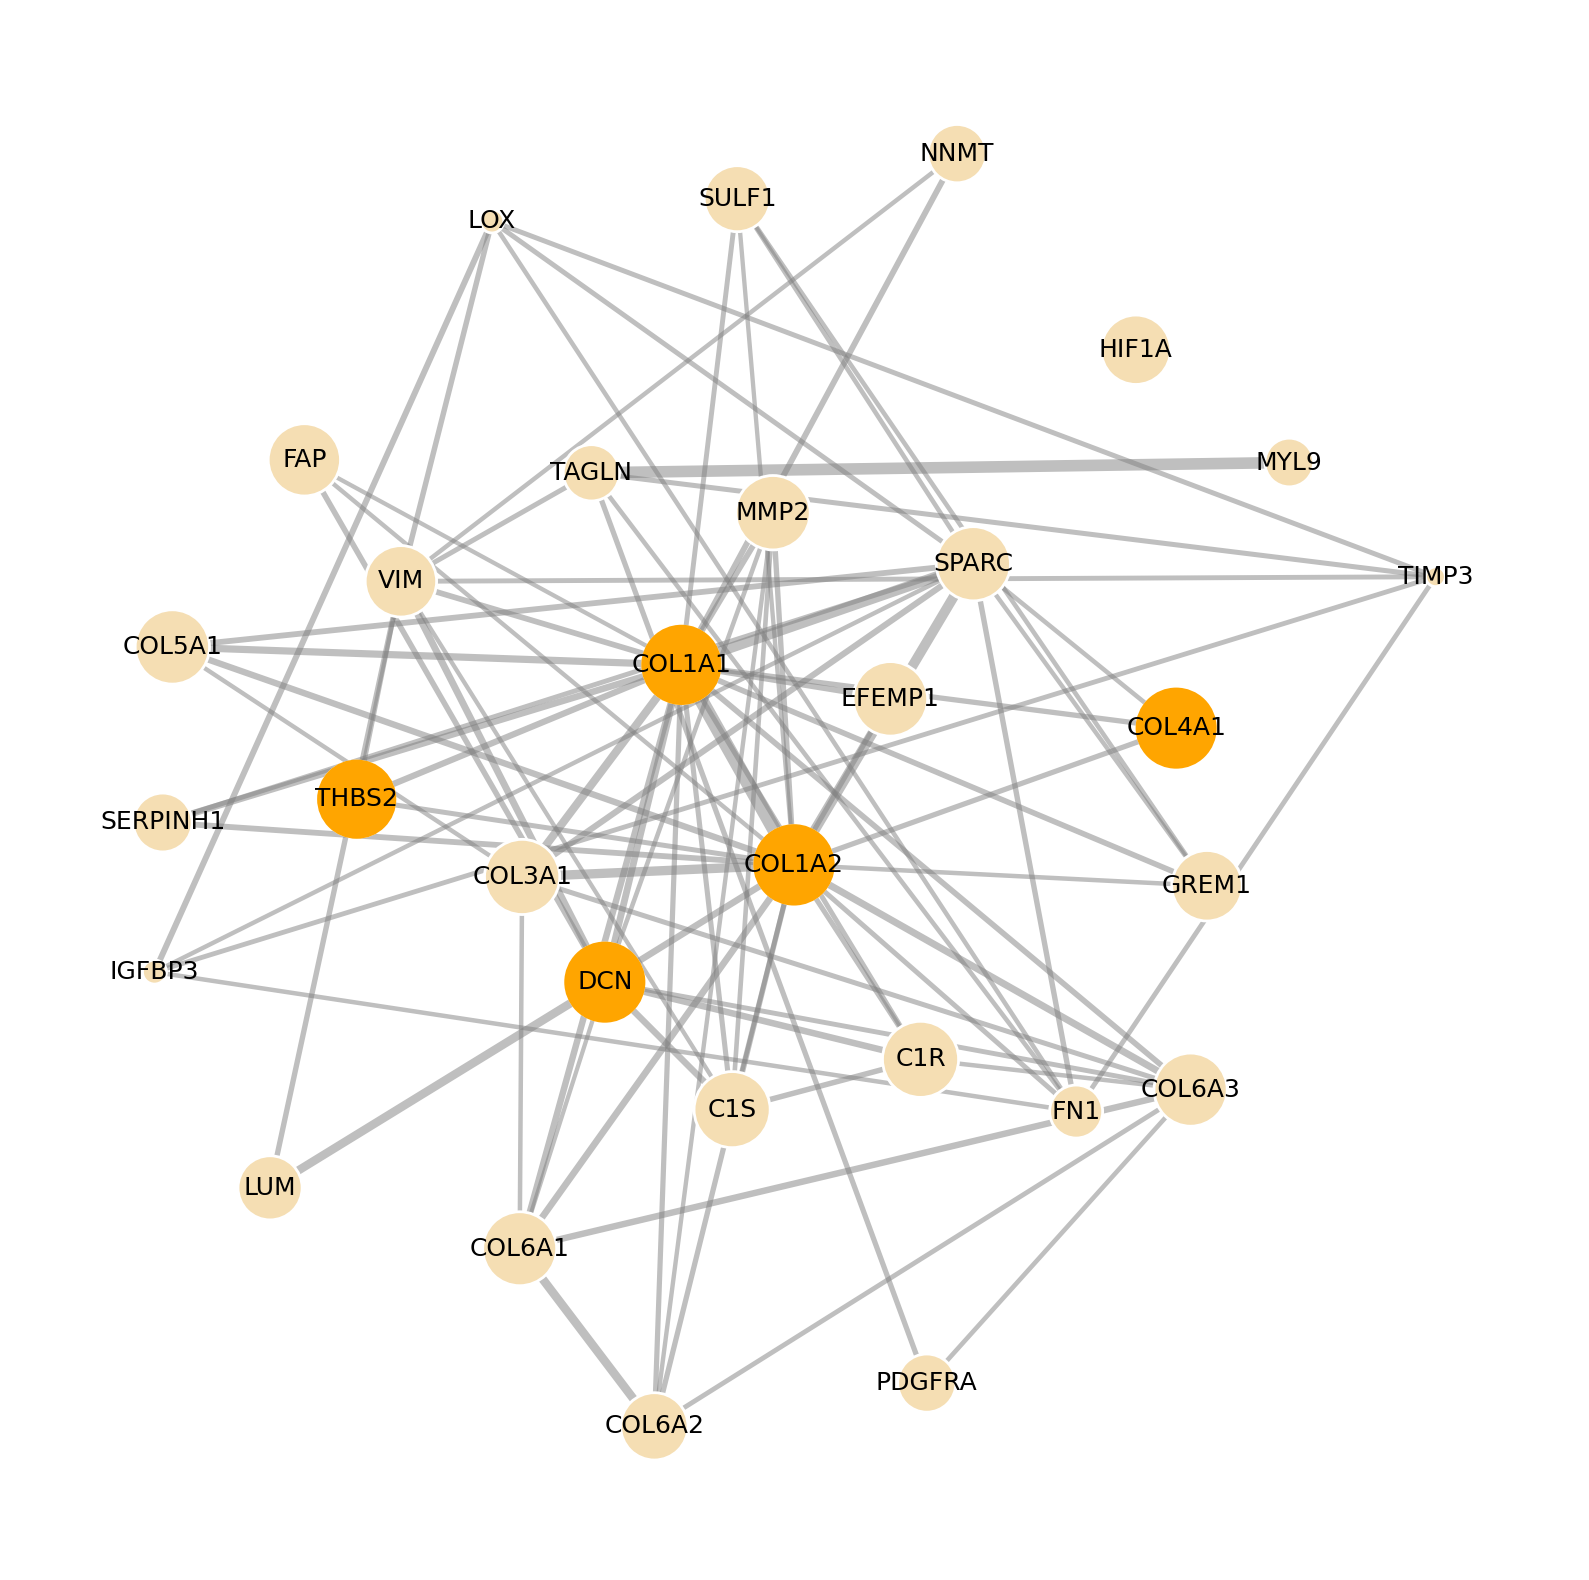

In [197]:
cent_vals = np.array(list(centrality.values()))
min_size = 50
max_size = 800
node_sizes = min_size + (cent_vals - cent_vals.min()) / (cent_vals.max() - cent_vals.min()) * (max_size - min_size)

weights = np.array([d["weight"] for u, v, d in G_thresh.edges(data=True)])
if len(weights) == 0:
    edge_widths = []
else:
    min_w = weights.min()
    max_w = weights.max()
    if max_w == min_w:
        edge_widths = [min_edge_width] * len(weights)
    else:
        edge_widths = 0.5 + (weights - min_w) / (max_w - min_w) * (5 - 0.5)

# Step 6 — layout
pos = nx.spring_layout(G_thresh, seed=42, k=1.5)

plt.figure(figsize=(10, 10))

# Draw edges
t = 0.25

edges_to_draw = [(u, v) for u, v, d in G_thresh.edges(data=True) if d['weight'] >= t]
edges_widths_to_draw = [width for (u, v), width in zip(G_thresh.edges(), edge_widths) if G_thresh[u][v]["weight"] >= t]

nx.draw_networkx_edges(G_thresh, pos, edgelist=edges_to_draw,
                       width=edges_widths_to_draw, alpha=0.5, edge_color="grey")

# Draw nodes
nx.draw_networkx_nodes(G_thresh, pos, node_size=[node_sizes[list(G_thresh.nodes()).index(n)] for n in G_thresh.nodes()], 
                       node_color="wheat", edgecolors='white')

labels = {g: g for g in G_thresh.nodes()}
nx.draw_networkx_labels(G_thresh, pos, labels=labels, font_size=9)

# Highlight top genes
top_genes = None
top_n_genes = 5

if top_genes is None and top_n_genes is not None:
    top_genes = sorted(centrality, key=centrality.get, reverse=True)[:top_n_genes]
if top_genes:
    top_genes = [g for g in top_genes if g in G_thresh.nodes()]  # only those present
    nx.draw_networkx_nodes(
        G_thresh, pos, nodelist=top_genes, node_color="orange",
        node_size=[node_sizes[list(G_thresh.nodes()).index(g)] for g in top_genes if g in G_thresh.nodes()]
    )
    # top_labels = {g: g for g in top_genes}
    # nx.draw_networkx_labels(G_thresh, pos, labels=top_labels, font_size=9)#, font_weight='bold')

plt.axis("off")
plt.show()

In [88]:
print(A_thresh.values[:5,:5])

[[0.         0.75862116 0.3856094  0.32883722 0.57124376]
 [0.75862116 0.         0.37522603 0.         0.55114126]
 [0.3856094  0.37522603 0.         0.39081244 0.        ]
 [0.32883722 0.         0.39081244 0.         0.        ]
 [0.57124376 0.55114126 0.         0.         0.        ]]


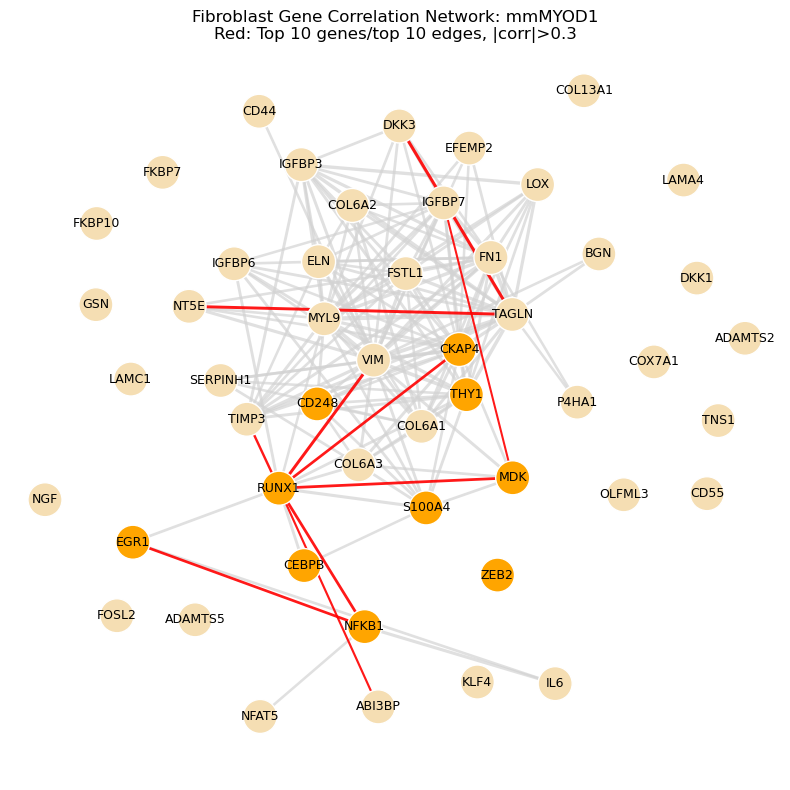

In [134]:
def plot_filtered_top_gene_network(
    A_condition,         # Adjacency matrix (pandas DataFrame)
    top_genes_df,        # DataFrame: columns=['condition','gene','KL_sum']
    top_edges_df,        # DataFrame: columns=['condition','gene_i','gene_j','value']
    condition,           # Condition to plot
    strength_threshold=0.3,   # Only draw edges with |correlation| above this
    n_top_nodes=10,
    n_top_edges=10,
    figsize=(8, 8)
):
    # 1. Get all genes in top_genes for this condition
    gene_list = top_genes_df[top_genes_df['condition'] == condition]['gene'].unique().tolist()

    # 2. Restrict adjacency to these genes
    A_sub = A_condition.loc[gene_list, gene_list]

    # 3. Get subgraph
    G = nx.from_pandas_adjacency(A_sub)

    # 4. Top 10 genes (red)
    top10_genes = top_genes_df[top_genes_df['condition'] == condition] \
                      .sort_values('KL_sum', ascending=False)['gene'].head(n_top_nodes).tolist()
    node_colors = ['orange' if node in top10_genes else 'wheat' for node in G.nodes]

    # 5. Top edges (red, both nodes in gene list)
    edges_cond = top_edges_df[top_edges_df['condition'] == condition]
    edges_cond = edges_cond[(edges_cond['gene_i'].isin(gene_list)) & (edges_cond['gene_j'].isin(gene_list))]
    edges_cond = edges_cond.sort_values('value', ascending=False).head(n_top_edges)
    top10_edges = set((row['gene_i'], row['gene_j']) for _, row in edges_cond.iterrows())

    # 6. Filter all edges by strength threshold, collect edge info for plotting
    gray_edges = []
    gray_widths = []
    red_edges = []
    red_widths = []
    for u, v in G.edges:
        # Edge always exists if in subgraph
        weight = np.abs(A_sub.loc[u, v])
        # Is this a top KL edge? (red)
        if ((u, v) in top10_edges) or ((v, u) in top10_edges):
            red_edges.append((u, v))
            red_widths.append(0.75 + 3.5 * weight)
        else:
            if weight >= strength_threshold:
                gray_edges.append((u, v))
                gray_widths.append(0.75 + 3.5 * weight)
            # else: skip weak non-highlight edges
            
    # 7. Draw!
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, seed=1)

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=600, edgecolors='white')
    # Draw gray edges first
    nx.draw_networkx_edges(G, pos, edgelist=gray_edges, width=gray_widths, edge_color='lightgray', alpha=0.7)
    # Draw red edges on top
    nx.draw_networkx_edges(G, pos, edgelist=red_edges, width=red_widths, edge_color='red', alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=9)

    plt.title(f'Fibroblast Gene Correlation Network: {condition}\n'
              f'Red: Top {n_top_nodes} genes/top {n_top_edges} edges, |corr|>{strength_threshold}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


condition = 'mmMYOD1'

plot_filtered_top_gene_network(
    A_condition=adjacency_matrices[condition],
    top_genes_df=top_genes,
    top_edges_df=top_edges,
    condition=condition,
    strength_threshold=0.3,     # Set as desired
    n_top_nodes=10,
    n_top_edges=10
)

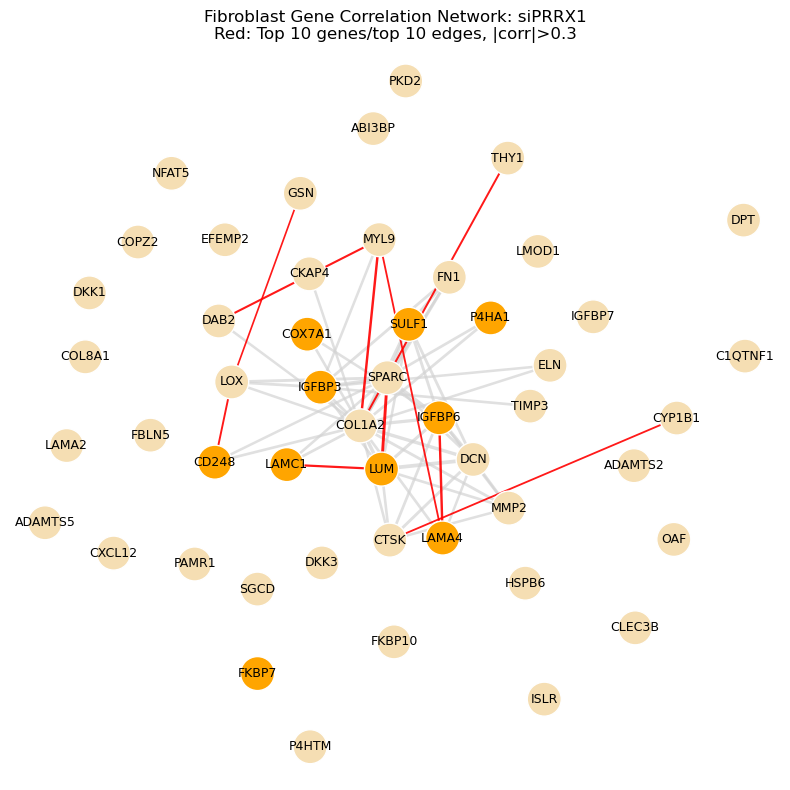

In [135]:
condition = 'siPRRX1'

plot_filtered_top_gene_network(
    A_condition=adjacency_matrices[condition],
    top_genes_df=top_genes,
    top_edges_df=top_edges,
    condition=condition,
    strength_threshold=0.3,     # Set as desired
    n_top_nodes=10,
    n_top_edges=10
)

#

## Signed adjacency matrices

In [36]:
adjacency_matrices = adjacency_matrices_signed.copy()

entropies = {}
KL_divergences = {}

# entropy
for cond, A in adjacency_matrices.items():
    upper_tri = np.triu_indices_from(A, k=1)
    values = A.values[upper_tri]
    values = values[~np.isnan(values)]
    
    p = values / np.sum(values)
    H = -np.sum(p * np.log2(p + 1e-12))
    entropies[cond] = H
    
entropy_df = pd.DataFrame(list(entropies.items()), columns=['condition', 'entropy'])
entropy_df = entropy_df.sort_values('entropy', ascending=False)

# KL divergence
control_A = adjacency_matrices['Control']
upper_tri = np.triu_indices_from(control_A, k=1)
print(f"Total edges in upper triangle: {len(control_A.values[upper_tri])}")

for condition, A in adjacency_matrices.items():
    mask_cond = ~np.isnan(A.values[upper_tri])
    print(f"{condition}: {mask_cond.sum()} edges")


# Create consistent mask based on edges that exist in *all* conditions
mask_upper = np.ones_like(control_A.values[upper_tri], dtype=bool)
for A in adjacency_matrices.values():
    mask_upper &= ~np.isnan(A.values[upper_tri])  # keep only edges present in all
    
print(f"Edges present in all conditions: {mask_upper.sum()} / {len(mask_upper)}")

control_values = control_A.values[upper_tri][mask_upper]
control_values = np.abs(control_values)
p_control = control_values / np.sum(control_values)

for condition, A in adjacency_matrices.items():
    if condition == 'Control':
        KL_divergences[condition] = 0.0
        continue

    values = A.values[upper_tri][mask_upper]  # same mask
    values = np.abs(values)

    if np.sum(values) == 0:
        KL_divergences[condition] = np.nan
        print(f"⚠️ Condition {condition} has zero-sum adjacency values → KL undefined")
        continue

    p_cond = values / np.sum(values)

    # Add small constant to avoid log(0)
    eps = 1e-12
    p_cond += eps
    p_control_adj = p_control + eps

    KL = np.sum(p_cond * np.log2(p_cond / p_control_adj))
    KL_divergences[condition] = KL
      
kl_df = pd.DataFrame(list(KL_divergences.items()), columns=['condition', 'KL_divergence'])
kl_df = kl_df.sort_values('KL_divergence', ascending=False)

display(entropy_df)
display(kl_df)

Total edges in upper triangle: 24090
Control: 23005 edges
mmMYOD1: 23436 edges
siPRRX1: 23871 edges
siPRRX1/mmMYOD1: 24090 edges
Edges present in all conditions: 22578 / 24090


,condition,entropy
3,siPRRX1/mmMYOD1,14.552302
2,siPRRX1,14.541153
1,mmMYOD1,14.512670
0,Control,14.487972


,condition,KL_divergence
3,siPRRX1/mmMYOD1,0.003937
1,mmMYOD1,0.003746
2,siPRRX1,0.001273
0,Control,0.000000


Signed adjacency matrix


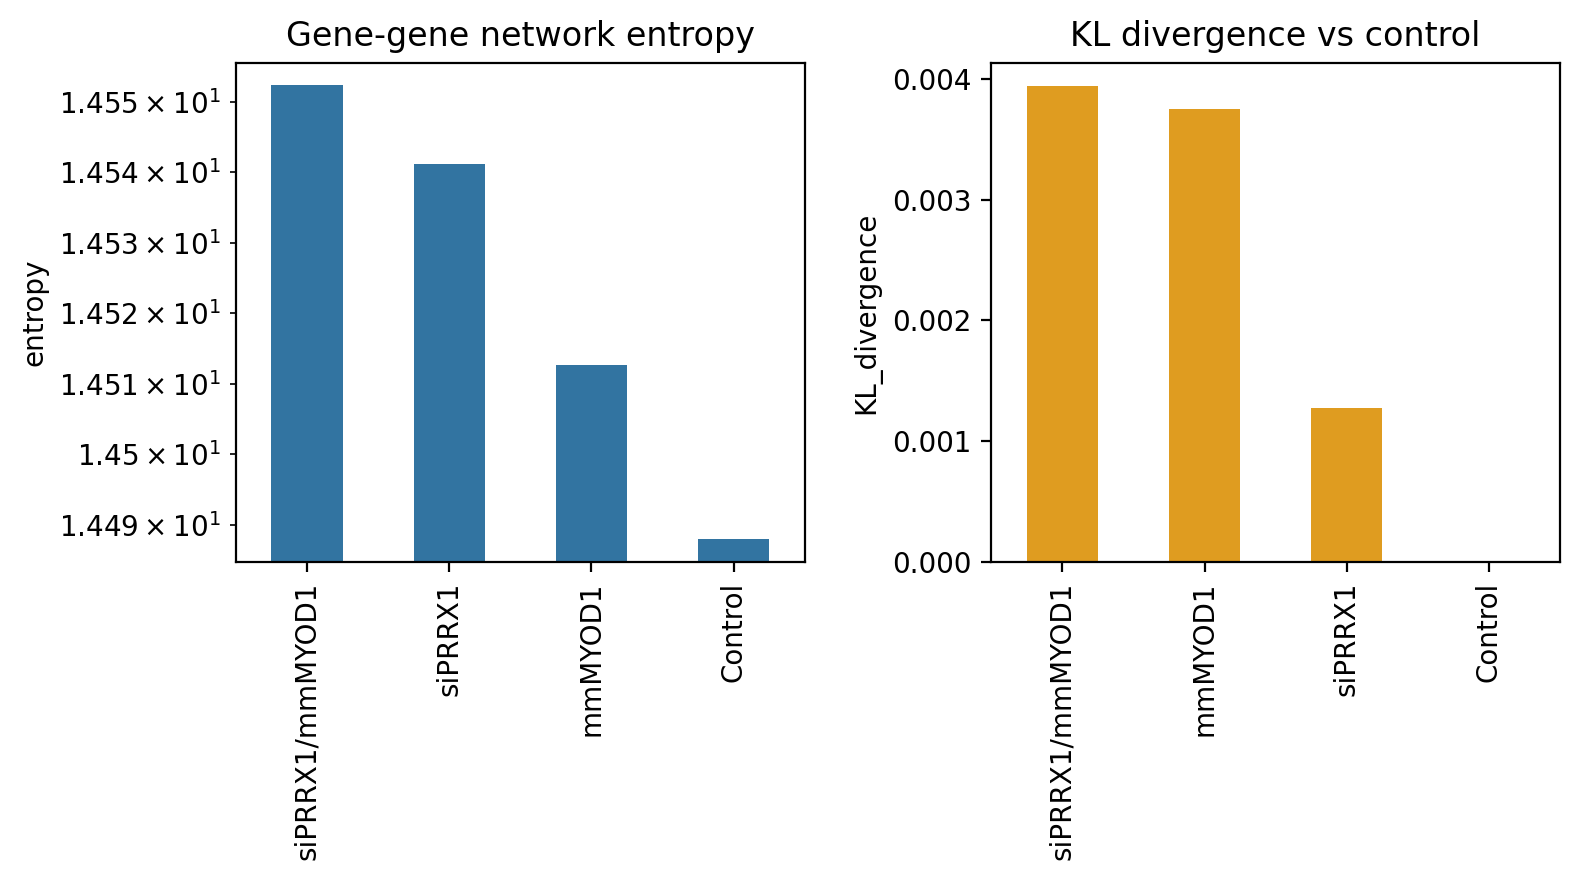

In [37]:
print("Signed adjacency matrix")
fig, axes = plt.subplots(1, 2, figsize=(8, 4.5), dpi=200)

sns.barplot(
    data=entropy_df,
    x='condition',
    y='entropy',
    width=0.5,
    ax=axes[0],
)

axes[0].tick_params(axis='x', labelrotation=90)
axes[0].set_xlabel("")
axes[0].set_title("Gene-gene network entropy")
axes[0].set_yscale('log')

sns.barplot(
    data=kl_df,
    x='condition',
    y='KL_divergence',
    width=0.5,
    color='orange',
    ax=axes[1],
)

axes[1].tick_params(axis='x', labelrotation=90)
axes[1].set_xlabel("")
axes[1].set_title("KL divergence vs control")

plt.tight_layout()
plt.show()

KL divergence --> high means the sign structure of correlations changes (in addition to magnitudes)